This tutorial takes a hands-on, open-ended approach—think of it as your chance to get more comfortable with PyTorch by building your own flow matching code from scratch. We provide boilerplate code for data loading and point you to useful velocity models in existing PyTorch libraries, but the implementation details are yours to explore!

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/florpi/heidelberg_generative_lectures/blob/main/4_galaxy_images.ipynb)

In [ ]:
import torch.nn as nn
import torch
import torchdiffeq
import torch.utils.data as data

import matplotlib.pyplot as plt
import numpy as np

from typing import List, Optional
from lightning import LightningDataModule
from torch.utils.data import DataLoader
from datasets import load_dataset

from torch.utils.data.dataloader import default_collate
from torchvision.transforms import CenterCrop

c:\Users\caran\Desktop\Tomas\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import sys, torch
print(sys.executable)
print(torch.version)
print(torch.version.cuda)
print(torch.cuda.is_available())

c:\Users\caran\Desktop\Tomas\.venv\Scripts\python.exe
<module 'torch.version' from 'c:\\Users\\caran\\Desktop\\Tomas\\.venv\\Lib\\site-packages\\torch\\version.py'>
12.8
True


Let's first write our data loading code. We will use galaxy image data from AstroClip (https://arxiv.org/abs/2310.03024)

In [ ]:
class ToRGB:
    """
    Transformation from raw image data (nanomaggies) to the rgb values displayed
    at the legacy viewer https://www.legacysurvey.org/viewer

    Code copied from
    https://github.com/legacysurvey/imagine/blob/master/map/views.py
    """

    def __init__(self, scales=None, m=0.03, Q=20, bands=["g", "r", "z"]):
        rgb_scales = {
            "u": (2, 1.5),
            "g": (2, 6.0),
            "r": (1, 3.4),
            "i": (0, 1.0),
            "z": (0, 2.2),
        }
        if scales is not None:
            rgb_scales.update(scales)

        self.rgb_scales = rgb_scales
        self.m = m
        self.Q = Q
        self.bands = bands
        self.axes, self.scales = zip(*[rgb_scales[bands[i]] for i in range(len(bands))])

        # rearange scales to correspond to image channels after swapping
        self.scales = [self.scales[i] for i in self.axes]

    def __call__(self, imgs):
        # Check image shape and set to C x H x W
        if imgs.shape[0] != len(self.bands):
            imgs = np.transpose(imgs, (2, 0, 1))

        I = 0
        for img, band in zip(imgs, self.bands):
            plane, scale = self.rgb_scales[band]
            img = np.maximum(0, img * scale + self.m)
            I = I + img
        I /= len(self.bands)

        Q = 20
        fI = np.arcsinh(Q * I) / np.sqrt(Q)
        I += (I == 0.0) * 1e-6
        H, W = I.shape
        rgb = np.zeros((H, W, 3), np.float32)
        for img, band in zip(imgs, self.bands):
            plane, scale = self.rgb_scales[band]
            rgb[:, :, plane] = (img * scale + self.m) * fI / I

        rgb = np.clip(rgb, 0, 1)
        return rgb


class AstroClipCollator:
    def __init__(
        self,
        center_crop: int = 144,
        bands: List[str] = ["g", "r", "z"],
        m: float = 0.03,
        Q: int = 20,
    ):
        self.center_crop = CenterCrop(center_crop)
        self.to_rgb = ToRGB(bands=bands, m=m, Q=Q)

    def _process_images(self, images):
        # convert to rgb
        img_outs = []
        for img in images:
            rgb_img = torch.tensor(self.to_rgb(img)[None, :, :, :])
            img_outs.append(rgb_img)
        images = torch.concatenate(img_outs)

        images = self.center_crop(images.permute(0, 3, 2, 1))
        return images

    def __call__(self, samples):
        # collate and handle dimensions
        samples = default_collate(samples)
        # process images
        samples["image"] = self._process_images(samples["image"])
        return samples

In [ ]:
cache_dir= "/cache_dir"
train_data = load_dataset(
    'mhsotoudeh/astroclip-mini',
    split='train',
    cache_dir=cache_dir,
    #streaming=True,
)

train_data = train_data.with_format('torch')

In [ ]:

batch_size = 16
train_loader = DataLoader(
            train_data,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=AstroClipCollator(
                center_crop=144,
                bands=["g", "r", "z"],
                m=0.03,
                Q=20,
            ),
        )

Let's now get a quick example batch from our data loader

In [ ]:
example_batch = next(iter(train_loader))

C:\Users\caran\AppData\Local\Temp\ipykernel_4680\1469827079.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  img = np.maximum(0, img * scale + self.m)
C:\Users\caran\AppData\Local\Temp\ipykernel_4680\1469827079.py:43: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  fI = np.arcsinh(Q * I) / np.sqrt(Q)


Now let's focus on the image content and plot it

In [ ]:
example_batch['image'].shape

torch.Size([16, 3, 144, 144])

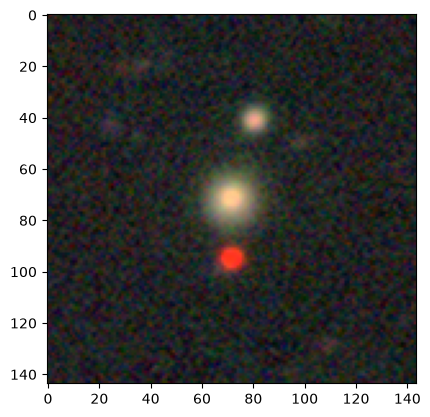

In [ ]:
# Note that the convention for images in pytorch is Channels x Height x Width,
# but for imshow is Height x Width x Channels.
plt.imshow(example_batch['image'][0].permute(1, 2, 0))

You can play around with two velcity models, a CNN based one (UNet) and a transformer based one (Vision Transformer from torchvision). Here is an example of a UNet that can be used for this problem:

In [ ]:
from diffusers import UNet2DModel

velocity_nn = UNet2DModel(
    sample_size=144,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 64, 128, 256),
    down_block_types= tuple(['DownBlock2D'] * 4),
    up_block_types= tuple(['UpBlock2D'] * 4),
)

Have fun :P

In [ ]:
class FlowMatching(nn.Module):
    def __init__(self, velocity_network, device='cuda'):
        super().__init__()
        self.velocity_net = velocity_network.to(device)
        self.device = device

    def sample_time(self, batch_size):
        """Sample random time steps between 0 and 1."""
        return torch.rand(batch_size, device=self.device)

    def interpolate(self, x0, x1, t):
        """
        Linear interpolation between noise (x0) and data (x1).
        At t=0: return x0 (noise)
        At t=1: return x1 (data)
        """
        # TODO: fill in the interpolant again
        if t.dim() == 1:
          t = t.view(t.shape[0], *([1] * (x1.dim() - 1)))
        return ((1-t)*x0) + (t*x1)

    def compute_target_velocity(self, x0, x1, t):
        """
        #TODO
        Compute the target velocity field that the neural network should learn.

        Think about this: if we have x_t = (1-t)*x0 + t*x1,
        what is dx_t/dt (the derivative with respect to time)?
        """
        # Your code here
        return x1 - x0

    def compute_loss(self, x1,):
        """
        Compute flow matching loss.

        Args:
            x1: data samples

        Returns:
            Loss value
        """
        # TODO: compute the flow matching loss given the functions above

        x0 = torch.randn_like(x1)
        t = self.sample_time(x1.shape[0])
        xt = self.interpolate(x0, x1, t)
        v_pred = self.velocity_net(sample=xt, timestep=t).sample
        v_target = self.compute_target_velocity(x0, x1, t)
        loss = torch.mean((v_pred - v_target)**2)
        return loss


    @torch.no_grad()
    def sample(self, target_shape=(2,), num_samples=10, num_steps=200):
        """
        Generate samples by integrating the learned velocity field.
        """
        self.velocity_net.eval()

        x0 = torch.randn(num_samples, *target_shape, device=self.device)
        t = torch.tensor([0.0, 1.0], device=self.device)

        def f(t, x):
            t_batch = t.repeat(num_samples)
            return self.velocity_net(sample=x, timestep=t_batch).sample

        return torchdiffeq.odeint(f, x0, t, method='dopri5')[-1]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
fm = FlowMatching(
    velocity_network=velocity_nn,
    device=device,
)

In [ ]:
fm.sample(target_shape=(3, 144, 144), num_samples=10, num_steps=200)

tensor([[[[-1.4313e+00, -1.0256e+00, -7.3236e-01,  ..., -7.1080e-01,
            3.9175e-01, -1.7957e-01],
          [-4.7372e-01, -1.8482e-02, -1.4365e+00,  ...,  2.1876e-02,
            1.6707e+00,  1.3956e+00],
          [-6.3177e-01,  4.4629e-01, -5.0823e-01,  ...,  1.3960e+00,
           -4.8049e-01,  1.5255e-01],
          ...,
          [-2.0711e-01,  3.0545e-01, -1.1120e+00,  ...,  5.1443e-01,
           -1.9971e+00, -5.2718e-01],
          [ 6.6670e-01,  5.6362e-01,  1.2874e+00,  ...,  1.3982e-01,
           -2.6417e-01,  7.5413e-01],
          [ 8.4985e-01,  1.6168e+00, -1.2957e+00,  ...,  1.2816e+00,
           -5.1179e-01, -5.6268e-01]],

         [[-4.4671e-01, -9.2480e-01, -1.3174e+00,  ..., -2.6574e+00,
            9.5460e-02,  7.1715e-01],
          [-3.6897e-01, -4.7805e-01,  2.9059e-02,  ...,  1.0014e+00,
           -1.1180e+00, -6.5054e-01],
          [ 8.0364e-01, -7.9264e-01,  5.3532e-01,  ...,  1.8802e+00,
           -1.4752e+00, -7.3041e-01],
          ...,
     

Training:   0%|          | 0/4000 [00:00<?, ?it/s]C:\Users\caran\AppData\Local\Temp\ipykernel_4680\1469827079.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  img = np.maximum(0, img * scale + self.m)
C:\Users\caran\AppData\Local\Temp\ipykernel_4680\1469827079.py:43: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  fI = np.arcsinh(Q * I) / np.sqrt(Q)
Training: 100%|██████████| 4000/4000 [09:28<00:00,  6.97it/s, Loss=0.1241]


Generating samples at step 4000...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13471673..1.2494615].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13299836..1.2319617].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16000254..1.5911523].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12097247..1.0030091].


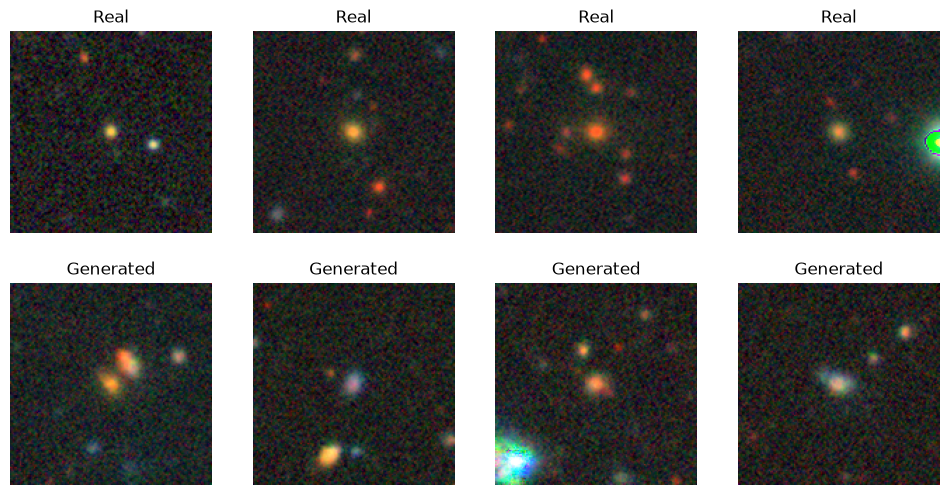

Training: 100%|██████████| 4000/4000 [10:57<00:00,  6.09it/s, Loss=0.1241]


In [ ]:
from tqdm import tqdm
optimizer = torch.optim.AdamW(fm.parameters(), lr=1.e-4, weight_decay=1e-4)
total_steps = 4_000
generate_every = 4_000
losses = []

train_iter = iter(train_loader)
fm.train()

step = 0
with tqdm(total=total_steps, desc="Training") as pbar:
    while step < total_steps:
        try:
            batch = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            batch = next(train_iter)

        x = batch['image'].to(device)
        loss = fm.compute_loss(x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(fm.parameters(), max_norm=1.0)

        optimizer.step()
        optimizer.zero_grad()

        pbar.set_postfix({'Loss': f'{loss:.4f}'})
        pbar.update(1)
        step += 1
        losses.append(loss.detach())

        if step % generate_every == 0:
            print(f"\nGenerating samples at step {step}...")
            samples = fm.sample(
                target_shape=(3, 144, 144),
                num_samples=4,
            ).detach().cpu().numpy()
            fig, axs = plt.subplots(2, 4, figsize=(12, 6))
            for i in range(4):
                axs[0, i].imshow(x[i].permute(1, 2, 0).cpu())
                axs[0, i].axis('off')
                axs[0, i].set_title('Real')
            for i in range(4):
                axs[1, i].imshow(samples[i].transpose(1, 2, 0))
                axs[1, i].axis('off')
                axs[1, i].set_title('Generated')
            plt.show()
            fm.velocity_net.train()

losses = torch.stack(losses)